# Notebook 2 — 1D Multilayer FEM Verification

Because a closed-form analytical solution is not generally available for layered profiles, verification is done in stages:

1. **Single-layer reduction** — one layer with uniform u₀ must match the classical Terzaghi solution.
2. **Single-layer reduction with Boussinesq u₀** — must match the arbitrary-u₀ analytical solver built from the same initial field.
3. **Interface pore-pressure continuity** — with two contrasting layers, u must remain continuous across the interface at all times.
4. **Darcy flux continuity** — the flux q = −(k/γw) ∂u/∂z must be continuous across the interface (enforced by the weak form as Cv × ∂u/∂z = const).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2
import os, sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical
from src.geotech_consolidation.models.terzaghi_1d.u0_analytical import Get_terzaghi1d_Analytical_u0
from src.geotech_consolidation.models.terzaghi_1d_multi.fem import Get_terzaghi1dMultilayer_FEA

sns.set_theme(style="whitegrid")

# Shared parameters
load       = 100.0        # applied load (kPa)
base       = 2.0          # strip-load base width (m)
num        = 100           # number of elements
nodes      = num + 1
T          = 365 * 24 * 60 * 60   # total time (s)
time_steps = 1000
N_terms    = 200 # bousinesq used nodes as the n terms 
time_days  = np.linspace(0.0, T / (60 * 60 * 24), time_steps)

# Single-layer profile used in reduction tests
depths = [5.0]
Cv     = [2e-7]   # m²/s
Mv     = [5e-4]   # m²/kN
H      = max(depths)
z      = -np.linspace(0.0, H, nodes)

gamma_w = 9.81   # unit weight of water (kN/m³)
k_list  = [Cv_i * Mv_i * gamma_w for Cv_i, Mv_i in zip(Cv, Mv)]

## Reduction Test 1 — Uniform Initial Condition

The multilayer solver given one layer must reproduce the single-layer FEM result.


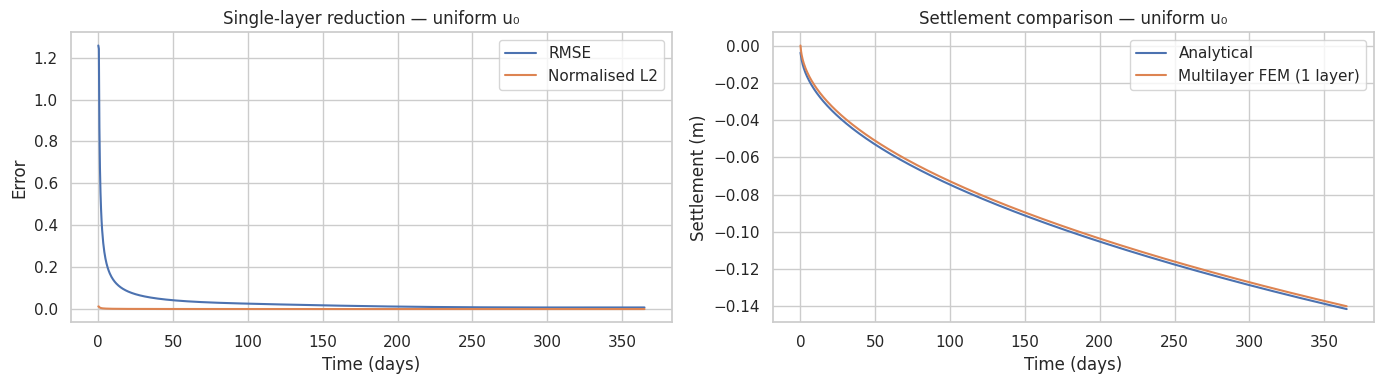

In [2]:
fem_s_u, fem_u_u, _ = Get_terzaghi1dMultilayer_FEA(
    depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=True
)
an_c_u, an_u_u, depth_u, time_u = Get_terzaghi1d_Analytical(
    H, num, load, T, time_steps, Cv[0], N_terms
)

error_u  = fem_u_u - an_u_u
rmse_u   = np.sqrt((error_u**2).mean(axis=1))
norm_l2_u = np.sqrt((error_u**2).sum(axis=1) / ((an_u_u**2).sum(axis=1) + 1e-12))
total_s   = Mv[0] * load * H
an_s_u    = an_c_u.mean(axis=1) * total_s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(time_days, rmse_u,    label="RMSE")
axes[0].plot(time_days, norm_l2_u, label="Normalised L2")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Error")
axes[0].set_title("Single-layer reduction — uniform u₀")
axes[0].legend()

axes[1].plot(time_days, -an_s_u,   label="Analytical")
axes[1].plot(time_days, -fem_s_u,  label="Multilayer FEM (1 layer)")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Settlement (m)")
axes[1].set_title("Settlement comparison — uniform u₀")
axes[1].legend()
plt.tight_layout()
plt.show()

## Reduction Test 2 — Boussinesq Initial Condition

The FEM initial field is used directly as u₀(z) for the arbitrary-u₀ analytical solver. Errors confirm that the two models are consistent for the same initial condition.


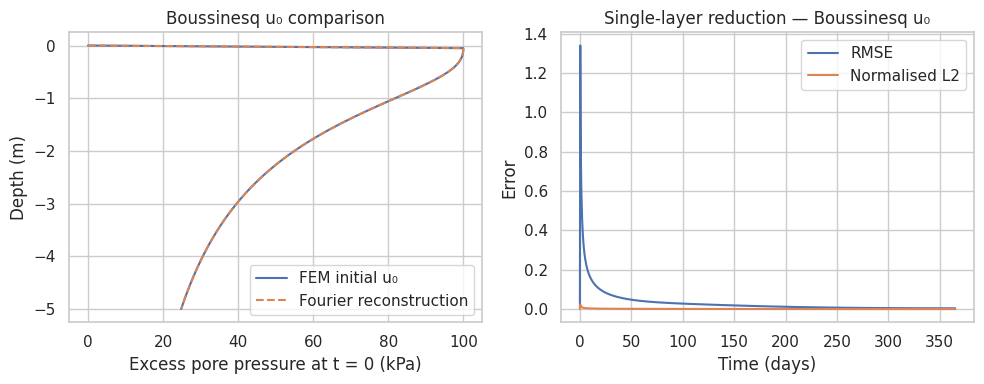

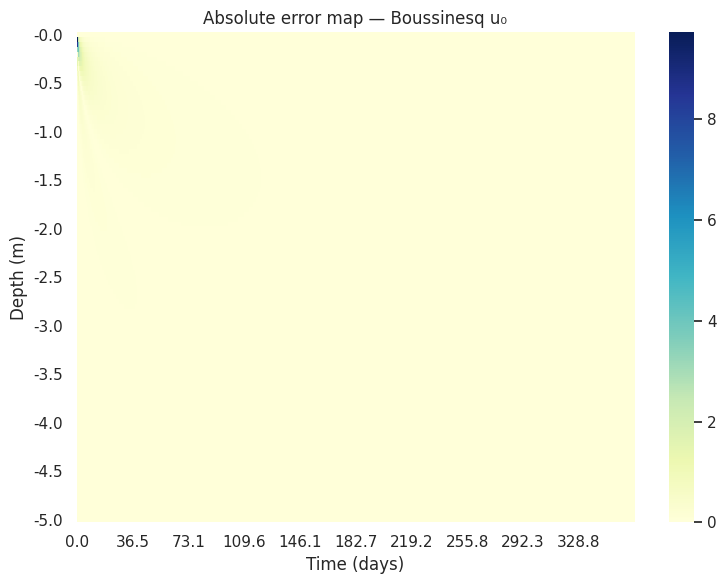

In [3]:
N_terms_b   = nodes # kept n number and the nodes be the same which was before predicted the best data

fem_s_b, fem_u_b, _ = Get_terzaghi1dMultilayer_FEA(depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=False)
u0_b = fem_u_b[0, :]

an_u_b, depth_b, time_b = Get_terzaghi1d_Analytical_u0(u0_b, H, num, T, time_steps, Cv[0], N_terms_b)

error_b   = fem_u_b - an_u_b
rmse_b    = np.sqrt((error_b**2).mean(axis=1))
norm_l2_b = np.sqrt((error_b**2).sum(axis=1) / ((an_u_b**2).sum(axis=1) + 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(u0_b,        z, label="FEM initial u₀")
axes[0].plot(an_u_b[0,:], z, "--", label="Fourier reconstruction")
axes[0].set_xlabel("Excess pore pressure at t = 0 (kPa)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Boussinesq u₀ comparison")
axes[0].legend()

axes[1].plot(time_b, rmse_b,    label="RMSE")
axes[1].plot(time_b, norm_l2_b, label="Normalised L2")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Error")
axes[1].set_title("Single-layer reduction — Boussinesq u₀")
axes[1].legend()
plt.tight_layout()
plt.show()

kx = max(1, len(time_b) // 10)
ky = max(1, len(z)      // 10)

plt.figure(figsize=(8, 6))
sns.heatmap(
    np.abs(error_b).T, annot=False, cmap="YlGnBu",
    xticklabels=False, yticklabels=False
)
ax = plt.gca()

ax.set_xticks(np.arange(0, len(time_b), kx) + 0.5)
ax.set_xticklabels([f"{time_b[i]:.1f}" for i in range(0, len(time_b), kx)], rotation=0)
ax.set_yticks(np.arange(0, len(z), ky) + 0.5)
ax.set_yticklabels([f"{z[i]:.1f}" for i in range(0, len(z), ky)], rotation=0)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Depth (m)")
ax.set_title("Absolute error map — Boussinesq u₀")

plt.tight_layout()
plt.show()

# Convergency Testt 

## Mesh Convergence — Boussinesq Initial Condition

Error is measured at the final time (t = 50 days) to avoid contamination from Gibbs oscillations at t = 0.

  Mesh size: 5 done
  Mesh size: 10 done
  Mesh size: 20 done
  Mesh size: 40 done
  Mesh size: 60 done
  Mesh size: 80 done


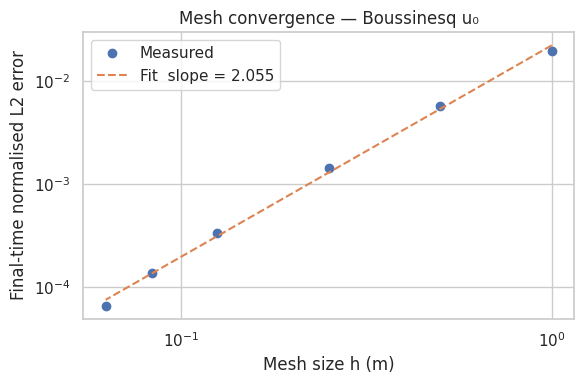

In [4]:
mesh_sizes      = np.array([5, 10, 20, 40, 60, 80], dtype=int)
T_conv          = 50 * 24 * 60 * 60
time_steps_conv = 5000

mesh_h  = H / mesh_sizes
mesh_l2 = []

for nx in mesh_sizes:
    _, fem_u, _ = Get_terzaghi1dMultilayer_FEA(
        depths, nx, load, T_conv, time_steps_conv, Cv, Mv, Base=base, U0=False
    )
    u0_b      = fem_u[0, :]
    N_terms_b = max(3, (nx + 1) // 2)
    an_u, _, _ = Get_terzaghi1d_Analytical_u0(u0_b, H, nx, T_conv, time_steps_conv, Cv[0], N_terms_b)
    err = fem_u[-1, :] - an_u[-1, :]
    dz  = H / nx
    l2  = np.sqrt(np.sum(err**2) * dz)
    ref = np.sqrt(np.sum(an_u[0, :]**2) * dz)
    mesh_l2.append(l2 / (ref + 1e-30))
    print(f"  Mesh size: {nx} done")

mesh_l2 = np.asarray(mesh_l2)
p_m, logC_m = np.polyfit(np.log(mesh_h), np.log(mesh_l2), 1)
fit_m = np.exp(logC_m) * mesh_h**p_m

plt.figure(figsize=(6, 4))
plt.loglog(mesh_h, mesh_l2, "o",  label="Measured")
plt.loglog(mesh_h, fit_m,   "--", label=f"Fit  slope = {p_m:.3f}")
plt.xlabel("Mesh size h (m)")
plt.ylabel("Final-time normalised L2 error")
plt.title("Mesh convergence — Boussinesq u₀")
plt.legend()
plt.tight_layout()
plt.show()

## Time-Step Convergence — Boussinesq Initial Condition

  100 steps: done
  200 steps: done
  400 steps: done
  800 steps: done
  1600 steps: done


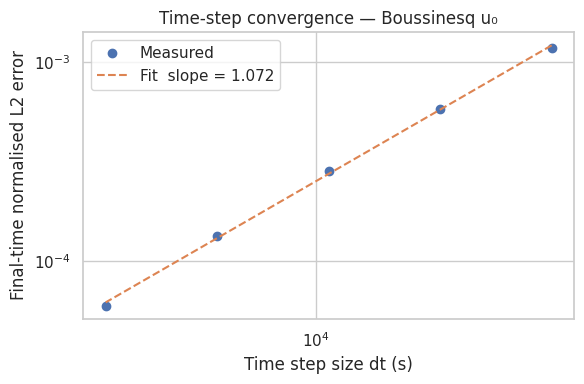

In [5]:
num_fixed       = 200
time_steps_list = np.array([100, 200, 400, 800, 1600], dtype=int)
dt_list         = T_conv / time_steps_list
time_l2         = []

N_terms_b_fixed = max(3, (num_fixed + 1) // 2)

for n_steps in time_steps_list:
    _, fem_u, _ = Get_terzaghi1dMultilayer_FEA(
        depths, num_fixed, load, T_conv, n_steps, Cv, Mv, Base=base, U0=False
    )
    u0_b = fem_u[0, :]
    an_u, _, _ = Get_terzaghi1d_Analytical_u0(u0_b, H, num_fixed, T_conv, n_steps, Cv[0], N_terms_b_fixed)
    err = fem_u[-1, :] - an_u[-1, :]
    dz  = H / num_fixed
    l2  = np.sqrt(np.sum(err**2) * dz)
    ref = np.sqrt(np.sum(an_u[0, :]**2) * dz)
    time_l2.append(l2 / (ref + 1e-30))
    print(f"  {n_steps} steps: done")

time_l2 = np.asarray(time_l2)
p_t, logC_t = np.polyfit(np.log(dt_list), np.log(time_l2), 1)
fit_t = np.exp(logC_t) * dt_list**p_t

plt.figure(figsize=(6, 4))
plt.loglog(dt_list, time_l2, "o",  label="Measured")
plt.loglog(dt_list, fit_t,   "--", label=f"Fit  slope = {p_t:.3f}")
plt.xlabel("Time step size dt (s)")
plt.ylabel("Final-time normalised L2 error")
plt.title("Time-step convergence — Boussinesq u₀")
plt.legend()
plt.tight_layout()
plt.show()

## Darcy Flux Continuity & Interface Pore-Pressure Continuity

For layered consolidation, the physically meaningful interface quantity is the Darcy flux

```
q = -(k / γw) · ∂u/∂z
```

If `Mv` differs between layers, neither `Cv` nor `∂u/∂z` should be expected to be continuous on their own, because `k = Cv · Mv · γw` changes with both parameters. The check below therefore looks directly at the one-sided Darcy flux above and below the interface at 1 months and 1 year.



In [6]:
# Two-layer profile — layer 1 same as single-layer reduction, layer 2 contrasting
depths_2L    = [2.5, 5.0]
Cv_2L        = [5e-7, 7e-8]
Mv_2L        = [5e-4, 5e-4]
k_2L         = [Cv_2L[i] * Mv_2L[i] * gamma_w for i in range(2)]

_, u_2L, _ = Get_terzaghi1dMultilayer_FEA(
    depths_2L, num, load, T, time_steps, Cv_2L, Mv_2L, Base=base, U0=False
)

H_2L        = max(depths_2L)                          # 5.0 m
z_2L        = np.linspace(0.0, H_2L, num + 1)         # positive depth: 0 (surface) → H (base)
interface_z = depths_2L[0]                             # 2.5 m (used in axhline as -interface_z)
dz          = H_2L / num
idx         = int(round(interface_z / H_2L * num))    # node index at interface

print(f"Two-layer FEM complete.  Interface at {interface_z} m (node {idx})")
print(f"k₁ = {k_2L[0]:.3e} m/s,  k₂ = {k_2L[1]:.3e} m/s")

Two-layer FEM complete.  Interface at 2.5 m (node 50)
k₁ = 2.453e-09 m/s,  k₂ = 3.434e-10 m/s


At interface  z = 2.5 m,  t = 30.0 days
Pore pressure:
  u (node above)    = 47.2742 kPa
  u (interface)     = 47.3343 kPa
  u (node below)    = 47.5272 kPa
Darcy flux  q = -(k/γw) · ∂u/∂z:
  q above interface = -3.008300e-10 m/s
  q below interface = -1.350116e-10 m/s
  Relative difference = 55.120%

At interface  z = 2.5 m,  t = 365.0 days
Pore pressure:
  u (node above)    = 5.5738 kPa
  u (interface)     = 5.6728 kPa
  u (node below)    = 6.3741 kPa
Darcy flux  q = -(k/γw) · ∂u/∂z:
  q above interface = -4.951578e-10 m/s
  q below interface = -4.909140e-10 m/s
  Relative difference = 0.857%



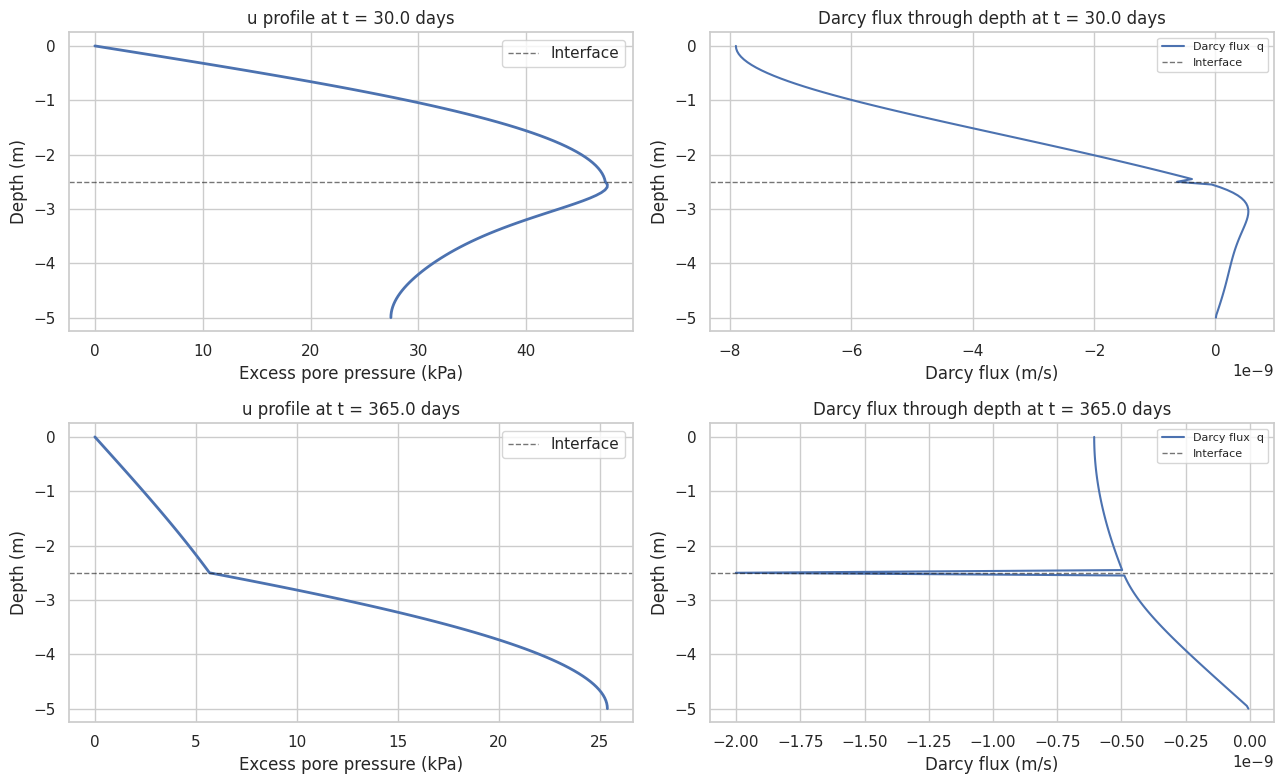

In [7]:
check_days = [30, 365.0]

def relative_difference(a, b):
    scale = max(abs(a), abs(b), 1e-30)
    return abs(a - b) / scale * 100.0

fig, axes = plt.subplots(len(check_days), 2, figsize=(13, 4 * len(check_days)), squeeze=False)

for row, target_day in enumerate(check_days):
    t_check = int(np.argmin(np.abs(time_days - target_day)))
    u_t = u_2L[t_check, :]

    grad_above = (u_t[idx]     - u_t[idx - 1]) / dz
    grad_below = (u_t[idx + 1] - u_t[idx])     / dz

    darcy_above = -(k_2L[0] / gamma_w) * grad_above
    darcy_below = -(k_2L[1] / gamma_w) * grad_below
    darcy_rel_diff = relative_difference(darcy_above, darcy_below)

    print(f"At interface  z = {interface_z} m,  t = {time_days[t_check]:.1f} days")
    print("Pore pressure:")
    print(f"  u (node above)    = {u_t[idx-1]:.4f} kPa")
    print(f"  u (interface)     = {u_t[idx]:.4f} kPa")
    print(f"  u (node below)    = {u_t[idx+1]:.4f} kPa")
    print("Darcy flux  q = -(k/γw) · ∂u/∂z:")
    print(f"  q above interface = {darcy_above:.6e} m/s")
    print(f"  q below interface = {darcy_below:.6e} m/s")
    print(f"  Relative difference = {darcy_rel_diff:.3f}%\n")

    axes[row, 0].plot(u_t, -z_2L, linewidth=2)
    axes[row, 0].axhline(-interface_z, color="k", linestyle="--", linewidth=1, alpha=0.6, label="Interface")
    axes[row, 0].set_xlabel("Excess pore pressure (kPa)")
    axes[row, 0].set_ylabel("Depth (m)")
    axes[row, 0].set_title(f"u profile at t = {time_days[t_check]:.1f} days")
    axes[row, 0].legend()

    grad = np.gradient(u_t, z_2L)
    darcy_flux = -np.where(z_2L <= interface_z, k_2L[0] / gamma_w, k_2L[1] / gamma_w) * grad
    axes[row, 1].plot(darcy_flux, -z_2L, label="Darcy flux  q")
    axes[row, 1].axhline(-interface_z, color="k", linestyle="--", linewidth=1, alpha=0.6, label="Interface")
    axes[row, 1].set_xlabel("Darcy flux (m/s)")
    axes[row, 1].set_ylabel("Depth (m)")
    axes[row, 1].set_title(f"Darcy flux through depth at t = {time_days[t_check]:.1f} days")
    axes[row, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()